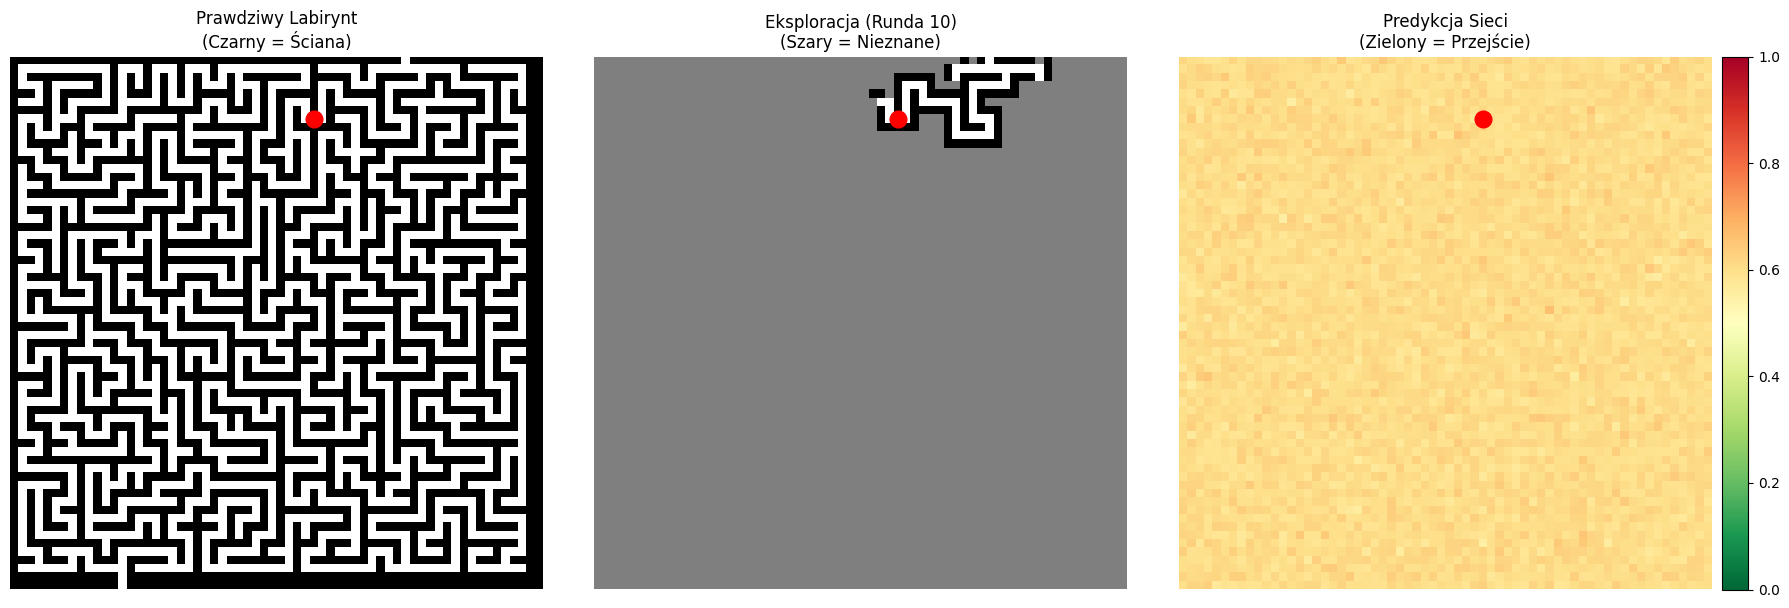

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Ścieżka do wyników (zmień na tę ze swoich logów)
output_dir = "outputs/2026-04-18/15-32-30/" 
round_idx = 10

# 2. Wczytanie danych
true_maze = np.load(os.path.join(output_dir, "true_maze.npy"))
mean_pred = np.load(os.path.join(output_dir, f"mean_pred_round_{round_idx}.npy"))
explored_mask = np.load(os.path.join(output_dir, f"explored_mask_round_{round_idx}.npy"))
pos = np.load(os.path.join(output_dir, f"pos_round_{round_idx}.npy"))

# Tworzymy figurę
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- PLOT 1: Prawdziwy Labirynt ---
# 'binary' mapuje 0 (ścieżka) na biały i 1 (ściana) na czarny.
axes[0].imshow(true_maze, cmap="binary", vmin=0, vmax=1)
axes[0].plot(pos[1], pos[0], "ro", markersize=12)
axes[0].set_title("Prawdziwy Labirynt\n(Czarny = Ściana)")

# --- PLOT 2: Wiedza Agenta ---
# 0.5 to szara mgła dla nieodkrytych pól
knowledge_map = np.full(true_maze.shape, 0.5)
knowledge_map[explored_mask] = true_maze[explored_mask]
axes[1].imshow(knowledge_map, cmap="binary", vmin=0, vmax=1)
axes[1].plot(pos[1], pos[0], "ro", markersize=12)
axes[1].set_title(f"Eksploracja (Runda {round_idx})\n(Szary = Nieznane)")

# --- PLOT 3: Predykcja SIREN ---
# RdYlGn_r: 1 (Ściana) = Czerwony, 0 (Puste) = Zielony
im = axes[2].imshow(mean_pred, cmap="RdYlGn_r", vmin=0, vmax=1)
axes[2].plot(pos[1], pos[0], "ro", markersize=12)
axes[2].set_title("Predykcja Sieci\n(Zielony = Przejście)")

# --- KLUCZOWA FIX: Synchronizacja rozmiarów ---
# Dodajemy cax (miejsce na colorbar) do KAŻDEGO wykresu.
# Dla pierwszych dwóch robimy je niewidoczne, dzięki czemu 
# wszystkie trzy labirynty będą miały IDENTYCZNY rozmiar w pikselach.
for i in range(3):
    divider = make_axes_locatable(axes[i])
    cax = divider.append_axes("right", size="5%", pad=0.1)
    if i == 2:
        plt.colorbar(im, cax=cax)
    else:
        cax.axis('off') # Niewidzialny margines dla wyrównania

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()